# Training a CNN on the PAMAP2 windows

This notebook trains a 1-D convolutional network that reads the raw filtered windows and learns
its own features, in place of the hand-crafted Table 3 features the classical models
(`modeling.py`) use. It is the Conv1d-CNN of Yang et al. (Section III-C-2, Table 5).

The network is scored two ways at each activity grouping. The first is GroupKFold grouped by
interval, where each interval stays in one fold but a person's other intervals can fall in the
training fold. The second is leave-one-subject-out (LOSO), which holds out a whole person at a
time. The notebook reports accuracy, precision, recall, and f1 for both, along with learning
curves and confusion matrices.

**Groupings.** `raw` (12 activities), `grouped9` (9 classes, remapping `2->1`, `7->4`, `17->16`),
and `lmh` (low, medium, and high). Set `GROUPINGS` in section 1.

**Environment.** The network needs a working keras and backend. Run it in `heartbeats_nn`, created
from `nn_environment.yml`. It does not run in `erdos_ds_environment`, whose tensorflow aborts on
import.

## 1. Setup

In [1]:
# Reduce TensorFlow's log output. Must be set before keras imports it.
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.makedirs("cnn_outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import set_style
set_style("darkgrid")

from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

from data_preprocessing import HeartbeatDataProcessor
import cnn_modeling as cm

# Paths and training knobs.
DATA_DIR = "../data/PAMAP2_Dataset/Protocol/"   # raw subjectNNN.dat files
INDEX_DIR = "./"                                # holds filtered_activities.csv
SUBJECTS = range(101, 109)                      # subjects 101..108, with 109 dropped as in the paper
GROUPINGS = ["raw", "grouped9", "lmh"]          # activity groupings to score
EPOCHS = 20
BATCH_SIZE = 256
SEED = 440                                       # fixed seed, for reproducible folds
N_SPLITS = 5                                     # GroupKFold folds, grouped by interval

## 2. Preprocess the subjects

`preprocess_subjects` interpolates the short gaps, applies the median and Butterworth low-pass
filter, and slides the window over each labelled interval, leaving the windows in
`processor.subject_segment_dict`. The CNN reads those windows raw.

In [2]:
processor = HeartbeatDataProcessor(DATA_DIR, INDEX_DIR, verbose=True)
processor.preprocess_subjects(SUBJECTS)

Selected DataFrame columns have 0.2913% NaNs.
Interpolating selected columns...


Selected DataFrame columns now have 0.019% NaNs!



successfully loaded subject 101


Selected DataFrame columns have 0.4147% NaNs.
Interpolating selected columns...


Selected DataFrame columns now have 0.0327% NaNs!



...

Selected DataFrame columns now have 0.0241% NaNs!



successfully loaded subject 107


Selected DataFrame columns have 0.442% NaNs.
Interpolating selected columns...


Selected DataFrame columns now have 0.0382% NaNs!



successfully loaded subject 108


## 3. Build the CNN input tensor

The `build_cnn_arrays` helper stacks the windows into the `(n_windows, window_length, n_channels)`
tensor a `Conv1D` reads. The depth is the 27 motion axes, leaving out heart rate as in the
paper's IMU-only Conv1d-CNN. The `y` array is each window's raw activity, which the groupings
remap. The `groups` array is the subject each window came from, for the LOSO split, and `intervals`
is the interval each window came from, for the GroupKFold split.

In [3]:
X, y, groups, intervals = cm.build_cnn_arrays(processor, return_intervals=True)

print("X shape:", X.shape, "  (windows, window_length, channels)")
print("raw classes (activity_id):", np.unique(y))
print("windows per subject:", {int(s): int(n) for s, n in zip(*np.unique(groups, return_counts=True))})

X shape: (18103, 201, 27)   (windows, window_length, channels)
raw classes (activity_id): [ 1  2  3  4  5  6  7 12 13 16 17 24]
windows per subject: {101: 2331, 102: 2464, 103: 1611, 104: 2171, 105: 2555, 106: 2344, 107: 2173, 108: 2454}


## 4. The architecture

The `build_cnn` helper stacks three `Conv1D`, batch-norm, and max-pool blocks, then a flatten, a
dropout, a dense hidden layer, and a dense softmax output. The convolution slides along time with
the 27 channels as depth, so `input_shape = (window_length, 27)`. Calling `model.summary()`
confirms the shapes flow through and the parameter count is reasonable. This model is only for
inspection, since the evaluations below build a fresh one per fold, sized to each grouping's
classes.

In [4]:
demo_model = cm.build_cnn(input_shape=(X.shape[1], X.shape[2]),
                          n_classes=len(np.unique(y)), seed=SEED)
demo_model.summary()

Model: "pamap2_conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 201, 32)        │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 201, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 201, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,068 (488.55 KB)

 Trainable params: 124,748 (487.30 KB)

 Non-trainable params: 320 (1.25 KB)

## 5. GroupKFold evaluation

For each grouping, `cnn_cv_scores` trains one network per fold under `GroupKFold` grouped by
interval, then pools the held-out predictions. The table gives the pooled accuracy, precision,
recall, and f1 (weighted).

In [5]:
gkf = GroupKFold(n_splits=N_SPLITS)

gkf_by_grouping = {}
for scheme in GROUPINGS:
    print(f"\n===== GroupKFold, grouping: {scheme} =====")
    y_scheme = cm.apply_grouping(y, scheme)
    gkf_by_grouping[scheme] = cm.cnn_cv_scores(X, y_scheme, intervals, gkf,
                                               epochs=EPOCHS, batch_size=BATCH_SIZE,
                                               seed=SEED, verbose=1)

rows = {}
for scheme, r in gkf_by_grouping.items():
    p, rec, f, _ = precision_recall_fscore_support(r["y_true"], r["y_pred"],
                                                    average="weighted", zero_division=0)
    rows[scheme] = [len(r["classes"]),
                    r["accuracy"].mean(), r["accuracy"].std(),
                    accuracy_score(r["y_true"], r["y_pred"]), p, rec, f]
gkf_summary = pd.DataFrame(rows,
    index=["n_classes", "mean_fold_accuracy", "std_fold_accuracy",
           "accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]).T.round(4)
gkf_summary


===== GroupKFold, grouping: raw =====


fold 1: accuracy 0.763, f1_weighted 0.766


fold 2: accuracy 0.731, f1_weighted 0.680


fold 3: accuracy 0.822, f1_weighted 0.833


fold 4: accuracy 0.739, f1_weighted 0.724


...

fold 2: accuracy 0.917, f1_weighted 0.915


fold 3: accuracy 0.884, f1_weighted 0.888


fold 4: accuracy 0.871, f1_weighted 0.872


fold 5: accuracy 0.880, f1_weighted 0.866


,n_classes,mean_fold_accuracy,std_fold_accuracy,accuracy,precision_weighted,recall_weighted,f1_weighted
raw,12.0,0.7420,0.0543,0.7419,0.7435,0.7419,0.7389
grouped9,9.0,0.8313,0.0348,0.8313,0.8426,0.8313,0.8333
lmh,3.0,0.8863,0.0160,0.8863,0.8863,0.8863,0.8848


## 6. GroupKFold confusion matrices

Every held-out window's true and predicted activity, pooled across folds, as raw counts. The
plotting below is copied from `Random_forest.ipynb` (its layout, colours, and combined-class
names) so the CNN matrices match that notebook's style, and only the data differs.

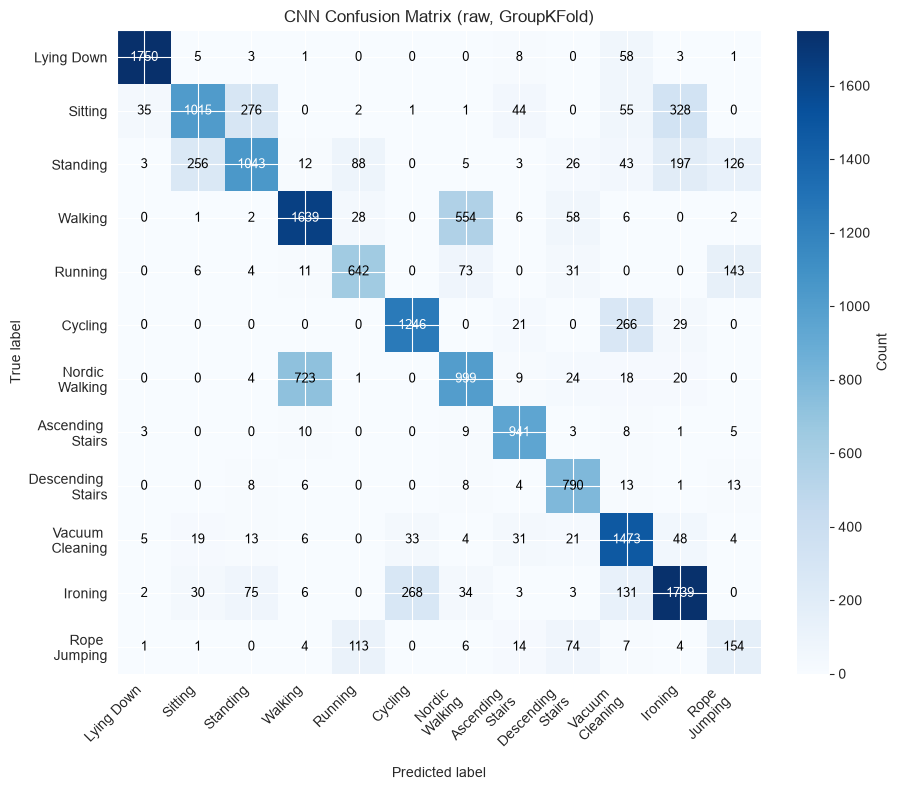

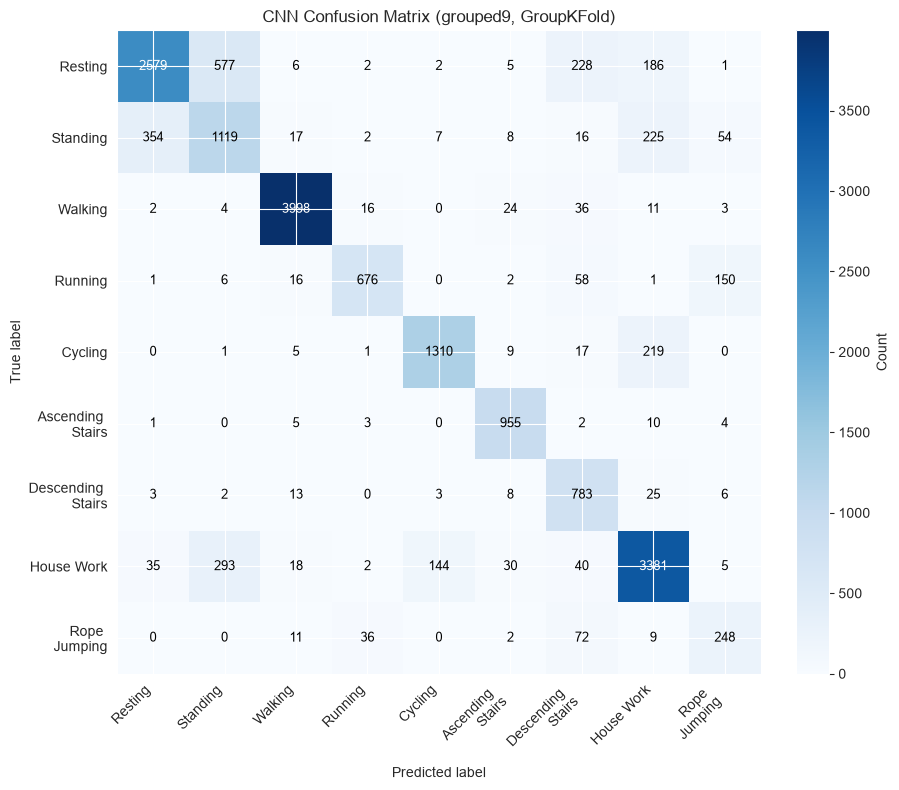

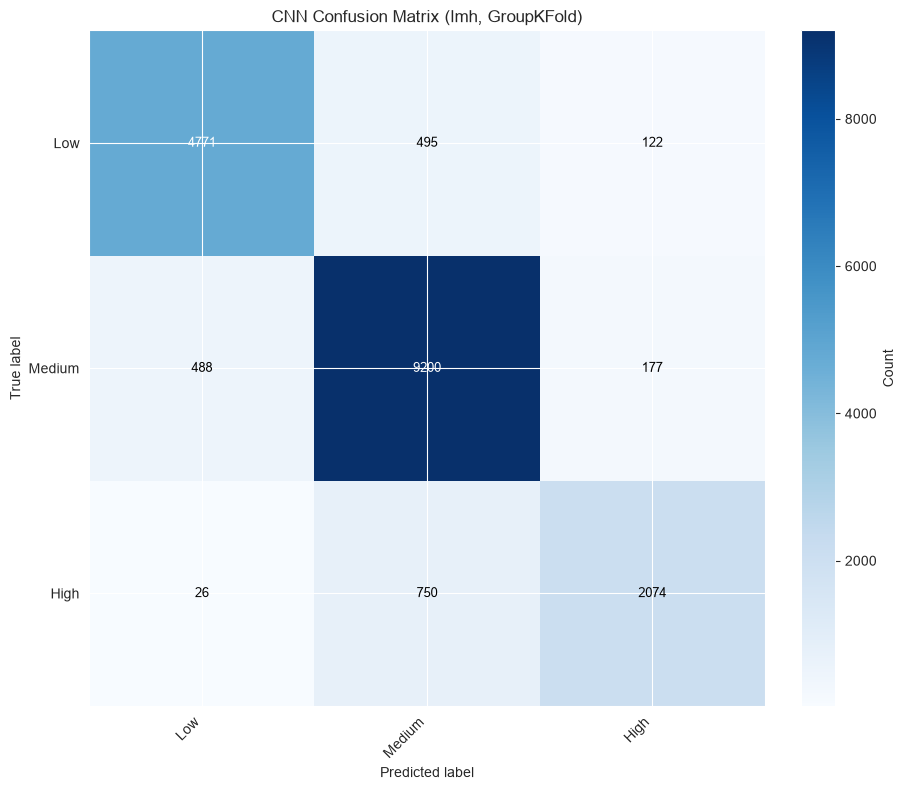

In [6]:
# Combined-class names per grouping.
NAMES = {
    "raw": {1: "Lying Down", 2: "Sitting", 3: "Standing", 4: "Walking", 5: "Running", 6: "Cycling",
            7: "Nordic \nWalking", 12: "Ascending \nStairs", 13: "Descending \nStairs",
            16: "Vacuum \nCleaning", 17: "Ironing", 24: "Rope \nJumping"},
    "grouped9": {1: "Resting", 3: "Standing", 4: "Walking", 5: "Running", 6: "Cycling",
                 12: "Ascending \nStairs", 13: "Descending \nStairs", 16: "House Work",
                 24: "Rope \nJumping"},
    "lmh": {101: "Low", 102: "Medium", 103: "High"},
}

def plot_cm_teamstyle(y_true, y_pred, labels_sorted, name_map, title, output_png):
    # Plotting copied from Random_forest.ipynb so the figures match that notebook's.
    labels = [name_map.get(int(l), f"ID{int(l)}") for l in labels_sorted]
    matrix = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    threshold = matrix.max() / 2 if matrix.size else 0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > threshold else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    plt.show()

for scheme, r in gkf_by_grouping.items():
    plot_cm_teamstyle(r["y_true"], r["y_pred"], r["classes"], NAMES[scheme],
                      title=f"CNN Confusion Matrix ({scheme}, GroupKFold)",
                      output_png=f"cnn_outputs/cnn_confusion_gkf_{scheme}.png")

## 7. Leave-one-subject-out evaluation

Each grouping is scored again with a whole person held out at a time, so the network is measured
only on people it never trained on. `loso_cnn_scores` trains one network per held-out subject and
pools the predictions, and the table gives the mean accuracy and f1 across subjects.

In [7]:
loso_by_grouping = {}
for scheme in GROUPINGS:
    print(f"\n===== LOSO, grouping: {scheme} =====")
    y_scheme = cm.apply_grouping(y, scheme)
    loso_by_grouping[scheme] = cm.loso_cnn_scores(X, y_scheme, groups,
                                                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                                                  seed=SEED, verbose=1)

loso_summary = pd.DataFrame(
    {scheme: [len(r["classes"]),
              r["accuracy"].mean(), r["accuracy"].std(),
              r["f1_weighted"].mean(), r["f1_weighted"].std()]
     for scheme, r in loso_by_grouping.items()},
    index=["n_classes", "mean_accuracy", "std_accuracy", "mean_f1", "std_f1"]).T.round(4)
loso_summary


===== LOSO, grouping: raw =====


subject 101: accuracy 0.703, f1_weighted 0.636


subject 102: accuracy 0.686, f1_weighted 0.650


subject 103: accuracy 0.970, f1_weighted 0.973


subject 104: accuracy 0.941, f1_weighted 0.944


...

subject 105: accuracy 0.934, f1_weighted 0.933


subject 106: accuracy 0.965, f1_weighted 0.964


subject 107: accuracy 0.994, f1_weighted 0.994


subject 108: accuracy 0.647, f1_weighted 0.651


,n_classes,mean_accuracy,std_accuracy,mean_f1,std_f1
raw,12.0,0.8202,0.1764,0.8023,0.1981
grouped9,9.0,0.8132,0.2194,0.8031,0.2263
lmh,3.0,0.9060,0.1138,0.9031,0.1160


## 8. Learning curves

Training against held-out accuracy and loss per epoch, for the first grouping's first held-out
subject under LOSO. The gap between the curves estimates the overfitting, and the held-out level
is the real cross-subject performance. `EPOCHS` is fixed in section 1 for every fold, not tuned
per subject.

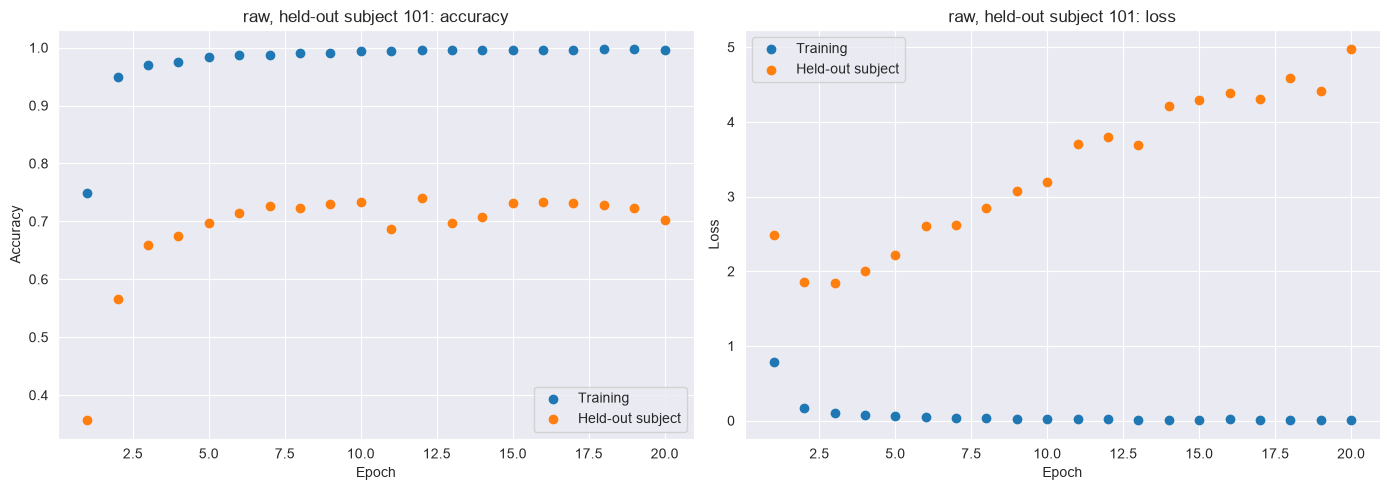

In [8]:
primary = GROUPINGS[0]
res = loso_by_grouping[primary]
subject = int(res["subjects"][0])
cm.plot_learning_curves(res["per_subject"][subject]["history"],
                        title=f"{primary}, held-out subject {subject}")
plt.show()

## 9. LOSO confusion matrices

The same pooled true-versus-predicted counts, now for the leave-one-subject-out predictions.

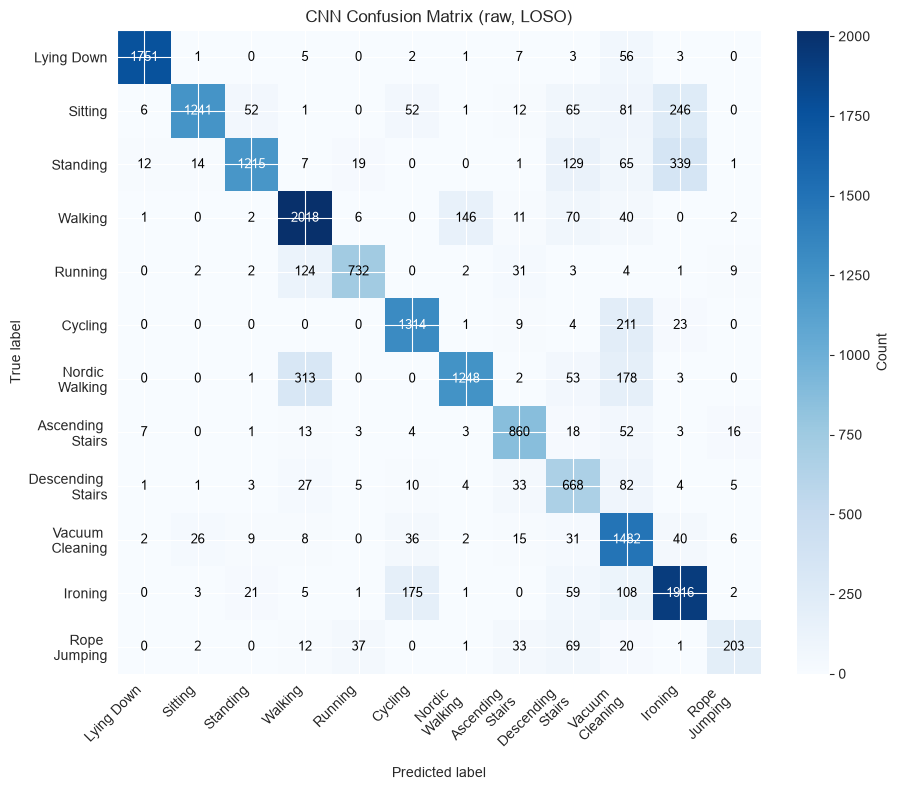

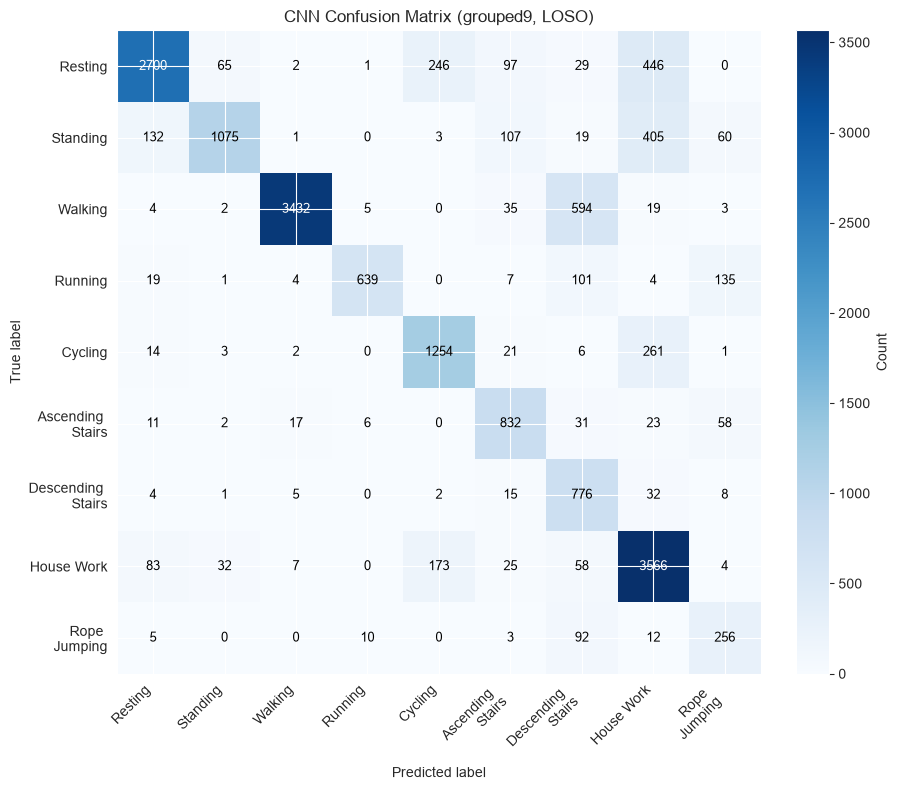

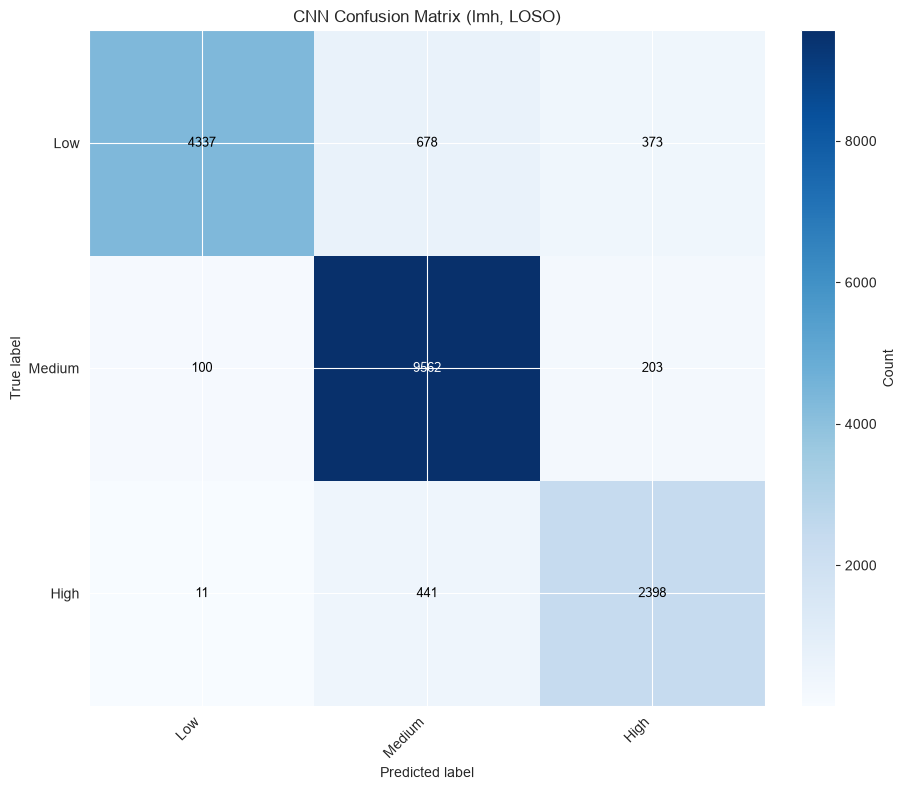

In [9]:
for scheme, r in loso_by_grouping.items():
    plot_cm_teamstyle(r["y_true"], r["y_pred"], r["classes"], NAMES[scheme],
                      title=f"CNN Confusion Matrix ({scheme}, LOSO)",
                      output_png=f"cnn_outputs/cnn_confusion_loso_{scheme}.png")

## 10. Save results

The GroupKFold summary, the per-subject LOSO table, and the pooled predictions from both
evaluations, so any confusion matrix can be redrawn without retraining.

In [10]:
gkf_summary.to_csv("cnn_outputs/cnn_groupkfold_results.csv")

counts = {int(s): int(n) for s, n in zip(*np.unique(groups, return_counts=True))}
subjects = loso_by_grouping[GROUPINGS[0]]["subjects"]
loso_out = pd.DataFrame({"n_windows": [counts[int(s)] for s in subjects]},
                        index=[int(s) for s in subjects])
loso_out.index.name = "held_out_subject"
for scheme, r in loso_by_grouping.items():
    loso_out[f"acc_{scheme}"] = r["accuracy"]
    loso_out[f"f1_{scheme}"] = r["f1_weighted"]
loso_out.to_csv("cnn_outputs/cnn_loso_results.csv")

np.savez("cnn_outputs/cnn_predictions.npz",
         **{f"gkf_{s}_true": r["y_true"] for s, r in gkf_by_grouping.items()},
         **{f"gkf_{s}_pred": r["y_pred"] for s, r in gkf_by_grouping.items()},
         **{f"loso_{s}_true": r["y_true"] for s, r in loso_by_grouping.items()},
         **{f"loso_{s}_pred": r["y_pred"] for s, r in loso_by_grouping.items()},
         **{f"{s}_classes": r["classes"] for s, r in gkf_by_grouping.items()})

gkf_summary

,n_classes,mean_fold_accuracy,std_fold_accuracy,accuracy,precision_weighted,recall_weighted,f1_weighted
raw,12.0,0.7420,0.0543,0.7419,0.7435,0.7419,0.7389
grouped9,9.0,0.8313,0.0348,0.8313,0.8426,0.8313,0.8333
lmh,3.0,0.8863,0.0160,0.8863,0.8863,0.8863,0.8848


## Notes

The two evaluations differ in what stays together across folds. GroupKFold grouped by interval
keeps each interval in one fold, but a person's other intervals can fall in the training fold, so
windows from that person appear in both training and testing. LOSO holds out every window of one
person at once. For this CNN the two scores come out close at each grouping.

Within each LOSO fold there is no leakage. The held-out subject never sets the scaling, selects
the weights, or stops training. The one caveat is that `EPOCHS` is fixed for every fold rather
than tuned per subject.

Accuracy rises as the labels get coarser, from `raw` to `grouped9` to `lmh`.

The window is 2 seconds long with a 1-second step. The paper uses 1-second windows.